In [1]:
!dpkg -l | grep tensorrt

In [2]:
!pip install nvidia-tensorrt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.8 MB/s eta 0:00:00
  Created wheel for tensorrt: filename=tensorrt-11.1.0.106-py3-none-any.whl size=16564 sha256=82eb574c902dc7ab5472e26269fad4141250b2e93bb6e26a695142ac2fe944fd
  Stored in directory: /root/.cache/pip/wheels/64/60/e6/9df6cdc73f3d2d55f99b57987892a29d470494bf419be000ad
  Created wheel for tensorrt_cu13: filename=tensorrt_cu13-11.1.0.106-py3-none-any.whl size=23074 sha256=42186d1ad97cf2217a44ca43704bdffb563beaed90d5f0507e715fe06f7af35d
  Stored in directory: /root/.cache/pip/wheels/77/0f/83/d9c20d0e840bfaf19d384d48255

In [3]:
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 12.5 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659496 sha256=3e3657eb4c2d1d77130921fbe6b3a647b76161aebe45311224ad069561e914f5
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [4]:
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit
import numpy as np
import cv2

ENGINE_PATH = "/content/model.engine"

logger = trt.Logger(trt.Logger.WARNING)
runtime = trt.Runtime(logger)

with open(ENGINE_PATH, "rb") as f:
    engine = runtime.deserialize_cuda_engine(f.read())

context = engine.create_execution_context()

print("✅ Engine loaded")

✅ Engine loaded


In [5]:
inputs = []
output_buffers = []
bindings = []

for i in range(engine.num_io_tensors):

    name = engine.get_tensor_name(i)

    shape = context.get_tensor_shape(name)
    size = trt.volume(shape)

    dtype = trt.nptype(engine.get_tensor_dtype(name))

    host_mem = cuda.pagelocked_empty(size, dtype)
    device_mem = cuda.mem_alloc(host_mem.nbytes)

    bindings.append(int(device_mem))

    if engine.get_tensor_mode(name) == trt.TensorIOMode.INPUT:

        inputs.append({
            "host": host_mem,
            "device": device_mem
        })

    else:

        output_buffers.append({
            "host": host_mem,
            "device": device_mem
        })

In [6]:
def preprocess(image_path, input_shape=(384, 384)):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, input_shape)

    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))  # CHW format
    img = np.expand_dims(img, axis=0)    # NCHW

    return img

In [7]:
def run_inference(image_path):

    input_data = preprocess(image_path)

    np.copyto(inputs[0]["host"], input_data.ravel())

    cuda.memcpy_htod(
        inputs[0]["device"],
        inputs[0]["host"]
    )

    context.execute_v2(bindings)

    results = []

    output_index = 0

    for i in range(engine.num_io_tensors):

        name = engine.get_tensor_name(i)

        if engine.get_tensor_mode(name) != trt.TensorIOMode.OUTPUT:
            continue

        cuda.memcpy_dtoh(
            output_buffers[output_index]["host"],
            output_buffers[output_index]["device"]
        )

        shape = tuple(context.get_tensor_shape(name))

        tensor = output_buffers[output_index]["host"].reshape(shape)

        results.append(tensor)

        output_index += 1

    return results

In [8]:
IMAGE_PATH = "/content/test.bmp"

outputs = run_inference(IMAGE_PATH)

print("✅ Inference Done")
print("Output tensors:")

outputs = run_inference(IMAGE_PATH)

print(outputs[0].shape)
print(outputs[1].shape)
print(outputs[2].shape)
for i, out in enumerate(outputs):
    print(f"\n--- Output {i} ---")
    print(out)  # first 50 values

✅ Inference Done
Output tensors:
(1, 100, 4)
(1, 100, 11)
(1, 100, 96, 96)

--- Output 0 ---
[[[0.43592584 0.28145552 0.04175011 0.15608919]
  [0.2813937  0.8524793  0.0417425  0.15912198]
  [0.597195   0.30290246 0.06820854 0.20787393]
  [0.28524014 0.27758822 0.04257155 0.16341496]
  [0.36116946 0.28134114 0.03933383 0.16450873]
  [0.59476846 0.83123505 0.06674125 0.20314509]
  [0.18557116 0.3055539  0.08373463 0.19902046]
  [0.4324914  0.85402185 0.04233978 0.15779616]
  [0.80083185 0.31674752 0.16775621 0.21199474]
  [0.19041559 0.6568843  0.11185484 0.04928903]
  [0.35818025 0.853146   0.04190104 0.1555543 ]
  [0.17553896 0.5688537  0.19727996 0.05814079]
  [0.7973864  0.8237378  0.16646229 0.2054393 ]
  [0.15284273 0.82438356 0.14803037 0.20279066]
  [0.1874011  0.47297314 0.11385405 0.05025372]
  [0.66451085 0.5707283  0.44691372 0.08259024]
  [0.8199096  0.571784   0.02184914 0.02474038]
  [0.6524698  0.5831584  0.02026388 0.02142795]
  [0.6939838  0.57345647 0.01714608 0.01889

In [9]:
import time
import numpy as np

times = []

for _ in range(100):

    start = time.perf_counter()

    run_inference("/content/test.bmp")

    end = time.perf_counter()

    times.append(end-start)

avg = np.mean(times)

print("="*40)
print("TensorRT Benchmark")
print("="*40)

print(f"Latency : {avg*1000:.2f} ms")
print(f"FPS      : {1/avg:.2f}")

TensorRT Benchmark
Latency : 26.80 ms
FPS      : 37.31


In [10]:
for i in range(engine.num_io_tensors):
    name = engine.get_tensor_name(i)
    mode = engine.get_tensor_mode(name)
    shape = context.get_tensor_shape(name)

    print(i)
    print("Name :", name)
    print("Mode :", mode)
    print("Shape:", shape)
    print("-"*40)

0
Name : input
Mode : TensorIOMode.INPUT
Shape: (1, 3, 384, 384)
----------------------------------------
1
Name : dets
Mode : TensorIOMode.OUTPUT
Shape: (1, 100, 4)
----------------------------------------
2
Name : labels
Mode : TensorIOMode.OUTPUT
Shape: (1, 100, 11)
----------------------------------------
3
Name : masks
Mode : TensorIOMode.OUTPUT
Shape: (1, 100, 96, 96)
----------------------------------------


In [11]:
class PostProcessor:

    def __init__(self,
                 conf_threshold=0.5,
                 mask_threshold=0.5,
                 background_class=10):

        self.idx_to_class = {
            0: "Valeo-MX",
            1: "solder",
            2: "solder-chip",
            3: "solder-large",
            4: "solder-long",
            5: "solder-middle",
            6: "solder-pin",
            7: "solder-square",
            8: "throughhole",
            9: "voids",
            10: "background"
        }

        self.CONF_THRESHOLD = conf_threshold
        self.MASK_THRESHOLD = mask_threshold
        self.BACKGROUND_CLASS = background_class

    @staticmethod
    def sigmoid(x):
        x = np.clip(x, -50, 50)
        return 1.0 / (1.0 + np.exp(-x))

    def convert_box(self, box, img_w, img_h):

        cx, cy, w, h = box

        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        x2 = (cx + w / 2) * img_w
        y2 = (cy + h / 2) * img_h

        return [int(x1), int(y1), int(x2), int(y2)]

    def process(self, outputs, original_size):

        img_h, img_w = original_size

        dets = outputs["dets"][0]
        labels = outputs["labels"][0]
        masks = outputs["masks"][0]

        final_boxes = []
        final_scores = []
        final_labels = []
        final_masks = []

        for i in range(len(dets)):

            probs = self.sigmoid(labels[i])

            class_id = int(np.argmax(probs))
            conf = float(probs[class_id])

            if conf < self.CONF_THRESHOLD:
                continue

            if class_id == self.BACKGROUND_CLASS:
                continue

            box = self.convert_box(dets[i], img_w, img_h)

            mask = self.sigmoid(masks[i])
            mask = (mask > self.MASK_THRESHOLD).astype(np.uint8)
            mask = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

            final_boxes.append(box)
            final_scores.append(conf)
            final_labels.append(class_id)
            final_masks.append(mask)

        return {
            "boxes": np.array(final_boxes),
            "scores": np.array(final_scores),
            "labels": np.array(final_labels),
            "masks": final_masks
        }

Detected objects: 31


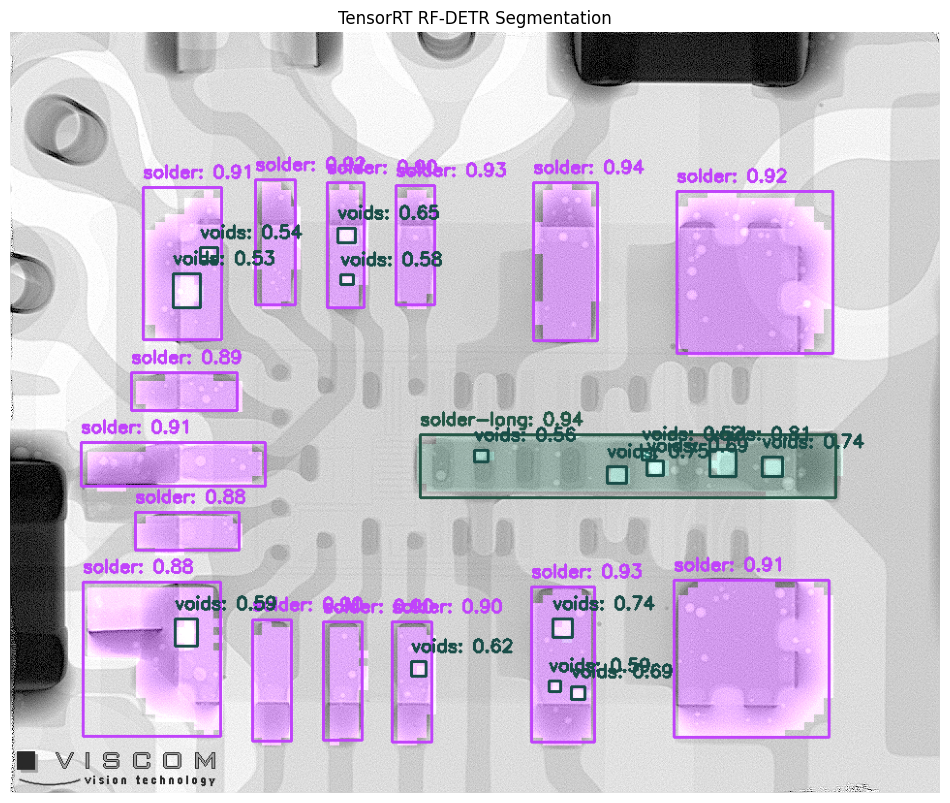

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Read original image
# -----------------------------
IMAGE_PATH = "/content/test.bmp"

img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -----------------------------
# TensorRT inference
# -----------------------------
trt_outputs = run_inference(IMAGE_PATH)

outputs = {
    "dets": trt_outputs[0],
    "labels": trt_outputs[1],
    "masks": trt_outputs[2]
}

# -----------------------------
# Postprocess
# -----------------------------
post = PostProcessor()

result = post.process(outputs, img.shape[:2])

print("Detected objects:", len(result["boxes"]))

# -----------------------------
# Random colors
# -----------------------------
np.random.seed(0)
colors = np.random.randint(0, 255, (100, 3))

vis = img_rgb.copy()

# -----------------------------
# Draw detections
# -----------------------------
for box, score, label, mask in zip(
        result["boxes"],
        result["scores"],
        result["labels"],
        result["masks"]):

    color = colors[int(label)].tolist()

    # Draw segmentation mask
    overlay = np.zeros_like(vis)
    overlay[mask == 1] = color
    vis = cv2.addWeighted(vis, 1.0, overlay, 0.45, 0)

    # Draw bounding box
    x1, y1, x2, y2 = box
    cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)

    # Draw class name
    cls_name = post.idx_to_class.get(int(label), "Unknown")

    cv2.putText(
        vis,
        f"{cls_name}: {score:.2f}",
        (x1, max(20, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )

# -----------------------------
# Show result
# -----------------------------
plt.figure(figsize=(12, 12))
plt.imshow(vis)
plt.axis("off")
plt.title("TensorRT RF-DETR Segmentation")
plt.show()

In [14]:
!pip install flask pyngrok opencv-python

In [ ]:
def run_inference(image):

    # preprocess must accept image (NOT path)
    input_data = preprocess(image)

    np.copyto(inputs[0]["host"], input_data.ravel())

    cuda.memcpy_htod(
        inputs[0]["device"],
        inputs[0]["host"]
    )

    # run inference
    context.execute_v2(bindings)

    results = []
    output_index = 0

    for i in range(engine.num_io_tensors):

        name = engine.get_tensor_name(i)

        if engine.get_tensor_mode(name) != trt.TensorIOMode.OUTPUT:
            continue

        cuda.memcpy_dtoh(
            output_buffers[output_index]["host"],
            output_buffers[output_index]["device"]
        )

        tensor = output_buffers[output_index]["host"]

        # safer reshape (avoid dynamic shape crash)
        shape = output_buffers[output_index]["host"].shape
        tensor = tensor.reshape(shape)

        results.append(tensor)
        output_index += 1

    return results

In [ ]:
def preprocess(image):
    # NOT cv2.imread inside here anymore
    img = cv2.resize(image, (640, 640))
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    return img

In [ ]:
# =========================
# INSTALL (run once)
# =========================
# !pip install fastapi uvicorn pyngrok python-multipart nest_asyncio opencv-python

import time
import numpy as np
import cv2
import threading
import nest_asyncio
import uvicorn

from fastapi import FastAPI, UploadFile, File
from pyngrok import ngrok

nest_asyncio.apply()


# =========================
# YOUR POSTPROCESSOR (UNCHANGED)
# =========================
class PostProcessor:

    def __init__(self,
                 conf_threshold=0.5,
                 mask_threshold=0.5,
                 background_class=10):

        self.idx_to_class = {
            0: "Valeo-MX",
            1: "solder",
            2: "solder-chip",
            3: "solder-large",
            4: "solder-long",
            5: "solder-middle",
            6: "solder-pin",
            7: "solder-square",
            8: "throughhole",
            9: "voids",
            10: "background"
        }

        self.CONF_THRESHOLD = conf_threshold
        self.MASK_THRESHOLD = mask_threshold
        self.BACKGROUND_CLASS = background_class

    @staticmethod
    def sigmoid(x):
        x = np.clip(x, -50, 50)
        return 1.0 / (1.0 + np.exp(-x))

    def convert_box(self, box, img_w, img_h):
        cx, cy, w, h = box

        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        x2 = (cx + w / 2) * img_w
        y2 = (cy + h / 2) * img_h

        return [int(x1), int(y1), int(x2), int(y2)]

    def process(self, outputs, original_size):

        img_h, img_w = original_size

        dets = outputs["dets"][0]
        labels = outputs["labels"][0]
        masks = outputs["masks"][0]

        final_boxes = []
        final_scores = []
        final_labels = []
        final_masks = []

        for i in range(len(dets)):

            probs = self.sigmoid(labels[i])

            class_id = int(np.argmax(probs))
            conf = float(probs[class_id])

            if conf < self.CONF_THRESHOLD:
                continue

            if class_id == self.BACKGROUND_CLASS:
                continue

            box = self.convert_box(dets[i], img_w, img_h)

            mask = self.sigmoid(masks[i])
            mask = (mask > self.MASK_THRESHOLD).astype(np.uint8)
            mask = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

            final_boxes.append(box)
            final_scores.append(conf)
            final_labels.append(class_id)
            final_masks.append(mask)

        return {
            "boxes": np.array(final_boxes),
            "scores": np.array(final_scores),
            "labels": np.array(final_labels),
            "masks": final_masks
        }


# =========================
# INIT PIPELINE OBJECTS
# =========================
postprocessor = PostProcessor()



# =========================
# FASTAPI APP
# =========================
app = FastAPI()


@app.post("/infer")
async def infer(file: UploadFile = File(...)):

    t0 = time.perf_counter()

    contents = await file.read()
    nparr = np.frombuffer(contents, np.uint8)
    frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    if frame is None:
        return {"error": "Invalid image"}

    # =========================
    # YOUR PIPELINE (INTEGRATED)
    # =========================
    trt_outputs = run_inference(frame)

    outputs = {
        "dets": trt_outputs[0],
        "labels": trt_outputs[1],
        "masks": trt_outputs[2]
    }

    result = postprocessor.process(outputs, frame.shape[:2])

    latency_ms = (time.perf_counter() - t0) * 1000

    return {
        "latency_ms": latency_ms,
        "frame_shape": frame.shape,
        "detections": {
            "boxes": result["boxes"].tolist(),
            "scores": result["scores"].tolist(),
            "labels": result["labels"].tolist()
        }
    }


# =========================
# START SERVER (COLAB SAFE)
# =========================
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="info")


ngrok.set_auth_token("3Ftg8uJeqiIBqCbOQf7loJq7Zpj_6JvptfA9iH5wcdKEsteQC")
public_url = ngrok.connect(8000).public_url

print("🔥 Public URL:", public_url)

thread = threading.Thread(target=run, daemon=True)
thread.start()

INFO:     154.80.51.148:0 - "POST /infer HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 62, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 90, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors

PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 5 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_3FtyRwbpPKo98BMaiAoSaDN4vqK, tn_3Ftzd3EteEuOVRmKk7DuwndQnEQ, tn_3FtzeFUoTm1VQF2Si5x05gdglcT, tn_3Fu0JV5FCpSwLZPAnRCzN81DrO0, tn_3Fu0NE6EVCIw2BAOvefzZbITSKt.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}


In [ ]:
import socket

def get_free_port():
    s = socket.socket()
    s.bind(("", 0))   # OS assigns free port
    port = s.getsockname()[1]
    s.close()
    return port

In [ ]:
from pyngrok import ngrok

class NgrokManager:
    def __init__(self):
        self.url = None

    def start(self, port):
        ngrok.kill()  # kill ALL old tunnels safely

        self.url = ngrok.connect(port, bind_tls=True).public_url
        print("🔥 NGROK URL:", self.url)

        return self.url

In [ ]:
def get_input_shape(engine):
    for i in range(engine.num_io_tensors):
        name = engine.get_tensor_name(i)
        if engine.get_tensor_mode(name) == trt.TensorIOMode.INPUT:
            return tuple(engine.get_tensor_shape(name))

In [ ]:
import cv2
import numpy as np

H, W = 384, 384

def preprocess(frame):
    frame = cv2.resize(frame, (W, H))   # IMPORTANT: (W, H)

    frame = frame.astype(np.float32) / 255.0
    frame = np.transpose(frame, (2, 0, 1))  # HWC → CHW

    frame = np.expand_dims(frame, axis=0)   # add batch → (1,3,384,384)

    return frame

In [ ]:
def run_inference(frame):

    input_data = preprocess(frame)

    expected = inputs[0]["host"].shape[0]  # should be 1*3*384*384 = 442368

    input_flat = input_data.ravel()

    # 🔒 HARD SAFETY CHECK (prevents crashes)
    if input_flat.size != expected:
        raise ValueError(f"Shape mismatch: got {input_flat.size}, expected {expected}")

    np.copyto(inputs[0]["host"], input_flat)

    cuda.memcpy_htod(inputs[0]["device"], inputs[0]["host"])
    context.execute_v2(bindings)

    # outputs
    cuda.memcpy_dtoh(output_buffers[0]["host"], output_buffers[0]["device"])
    cuda.memcpy_dtoh(output_buffers[1]["host"], output_buffers[1]["device"])
    cuda.memcpy_dtoh(output_buffers[2]["host"], output_buffers[2]["device"])

    dets = output_buffers[0]["host"].reshape(1, 100, 4)
    labels = output_buffers[1]["host"].reshape(1, 100, 11)
    masks = output_buffers[2]["host"].reshape(1, 100, 96, 96)

    return dets, labels, masks

In [ ]:
from fastapi import FastAPI, UploadFile, File
import traceback
import time

app = FastAPI()


@app.post("/infer")
async def infer(file: UploadFile = File(...)):

    try:
        contents = await file.read()
        nparr = np.frombuffer(contents, np.uint8)
        frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if frame is None:
            return {"status": "error", "message": "invalid image"}

        dets, labels, masks = run_inference(frame)

        return {
            "status": "ok",
            "detections": dets.tolist(),
            "labels": labels.tolist(),
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }

In [ ]:
import threading
import uvicorn

def start_server():
    port = get_free_port()

    print("🚀 Using port:", port)

    threading.Thread(
        target=lambda: uvicorn.run(app, host="0.0.0.0", port=port),
        daemon=True
    ).start()

    ngrok_url = NgrokManager().start(port)

    return ngrok_url

In [ ]:
print(start_server())

🚀 Using port: 54521


INFO:     Started server process [687]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:54521 (Press CTRL+C to quit)


🔥 NGROK URL: https://confess-county-december.ngrok-free.dev
https://confess-county-december.ngrok-free.dev


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3Ftg8uJeqiIBqCbOQf7loJq7Zpj_6JvptfA9iH5wcdKEsteQC")

import cv2
import numpy as np
import time
import tensorrt as trt
import pycuda.driver as cuda
# NOTE: pycuda.autoinit is intentionally NOT imported.
# We manage the CUDA context manually so it can be pushed/popped
# on the single worker thread that actually calls into CUDA.

from fastapi import FastAPI, UploadFile, File, Response
import uvicorn
import threading
import queue
from pyngrok import ngrok

import socket


def get_free_port():
    s = socket.socket()
    s.bind(("", 0))
    port = s.getsockname()[1]
    s.close()
    return port


# =========================
# FASTAPI
# =========================

app = FastAPI()

# =========================
# CUDA CONTEXT (created explicitly, owned by the worker thread)
# =========================

cuda.init()
cuda_device = cuda.Device(0)

ENGINE_PATH = "/content/model.engine"

H, W = 640,640


class PostProcessor:

    def __init__(self):
        self.idx_to_class = {
            0: "Valeo-MX",
            1: "solder",
            2: "solder-chip",
            3: "solder-large",
            4: "solder-long",
            5: "solder-middle",
            6: "solder-pin",
            7: "solder-square",
            8: "throughhole",
            9: "voids",
            10: "background"
        }
        self.class_colors = {
            0: (255, 0, 0),      # blue      - Valeo-MX
            1: (0, 255, 0),      # green     - solder
            2: (0, 0, 255),      # red       - solder-chip
            3: (255, 255, 0),    # cyan      - solder-large
            4: (255, 0, 255),    # magenta   - solder-long
            5: (0, 255, 255),    # yellow    - solder-middle
            6: (128, 0, 255),    # pink      - solder-pin
            7: (255, 128, 0),    # orange-ish- solder-square
            8: (0, 128, 255),    # orange    - throughhole
            9: (128, 255, 0),    # lime      - voids
            10: (128, 128, 128), # gray      - background (won't be drawn anyway)
        }

        self.CONF_THRESHOLD = 0.5
        self.MASK_THRESHOLD = 0.5
        self.BACKGROUND_CLASS = 10
    def get_color(self, cls_id):
        return self.class_colors.get(cls_id, (255, 255, 255))

    def sigmoid(self, x):
        x = np.clip(x, -50, 50)
        return 1 / (1 + np.exp(-x))

    def convert_box(self, box, img_w, img_h):
        cx, cy, w, h = box
        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        x2 = (cx + w / 2) * img_w
        y2 = (cy + h / 2) * img_h

        # Clamp to image bounds so cv2 drawing / mask indexing never
        # gets negative or out-of-range coordinates.
        x1 = int(np.clip(x1, 0, img_w - 1))
        y1 = int(np.clip(y1, 0, img_h - 1))
        x2 = int(np.clip(x2, 0, img_w - 1))
        y2 = int(np.clip(y2, 0, img_h - 1))
        return [x1, y1, x2, y2]

    def process(self, outputs, orig_shape):

        img_h, img_w = orig_shape

        dets = outputs["dets"][0]
        labels = outputs["labels"][0]
        masks = outputs["masks"][0]

        boxes, scores, cls_ids, final_masks = [], [], [], []

        for i in range(len(dets)):

            probs = self.sigmoid(labels[i])
            cls = int(np.argmax(probs))
            conf = float(probs[cls])

            if conf < self.CONF_THRESHOLD:
                continue

            if cls == self.BACKGROUND_CLASS:
                continue

            box = self.convert_box(dets[i], img_w, img_h)

            mask = self.sigmoid(masks[i])
            mask = (mask > self.MASK_THRESHOLD).astype(np.uint8)
            mask = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

            boxes.append(box)
            scores.append(conf)
            cls_ids.append(cls)
            final_masks.append(mask)

        return {
            "boxes": boxes,
            "scores": scores,
            "labels": cls_ids,
            "masks": final_masks
        }


post = PostProcessor()


def preprocess(frame):
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # confirmed: matches working Kaggle pipeline
    frame = cv2.resize(frame, (W, H))  # cv2.resize takes (W, H)
    frame = frame.astype(np.float32) / 255.0
    frame = np.transpose(frame, (2, 0, 1))  # HWC -> CHW
    frame = np.expand_dims(frame, axis=0)  # add batch -> (1,3,384,384)
    return np.ascontiguousarray(frame)


# =========================
# INFERENCE WORKER
# =========================
# All CUDA / TensorRT calls happen exclusively on this one background
# thread. The CUDA context is created and pushed here, and every request
# is executed via this thread through a queue, so there is never a
# mismatch between "thread that owns the context" and "thread that
# calls cuMemcpyHtoD / execute".

class InferenceWorker(threading.Thread):
    def __init__(self):
        super().__init__(daemon=True)
        self.task_queue = queue.Queue()
        self.ready = threading.Event()
        self.stream = None

    def run(self):
        # Create + push the CUDA context on THIS thread.
        self.cuda_ctx = cuda_device.make_context()

        try:
            logger = trt.Logger(trt.Logger.WARNING)
            runtime = trt.Runtime(logger)

            with open(ENGINE_PATH, "rb") as f:
                self.engine = runtime.deserialize_cuda_engine(f.read())

            self.context = self.engine.create_execution_context()
            self.stream = cuda.Stream()

            self.inputs = []
            self.output_buffers = []
            self.output_names = []
            self.bindings = []

            for i in range(self.engine.num_io_tensors):
                name = self.engine.get_tensor_name(i)
                is_input = self.engine.get_tensor_mode(name) == trt.TensorIOMode.INPUT

                if is_input:
                    shape = (1, 3, 384, 384)
                else:
                    if "dets" in name:
                        shape = (1, 100, 4)
                    elif "labels" in name:
                        shape = (1, 100, 11)
                    else:
                        shape = (1, 100, 96, 96)

                size = trt.volume(shape)
                dtype = trt.nptype(self.engine.get_tensor_dtype(name))

                host_mem = cuda.pagelocked_empty(size, dtype)
                device_mem = cuda.mem_alloc(host_mem.nbytes)

                self.bindings.append(int(device_mem))

                if is_input:
                    self.inputs.append({"host": host_mem, "device": device_mem, "name": name})
                else:
                    self.output_buffers.append({"host": host_mem, "device": device_mem, "shape": shape})
                    self.output_names.append(name)

                # Bind the tensor address up front (required for execute_v2/v3
                # depending on TRT version; harmless if execute_v2 ignores it).
                self.context.set_tensor_address(name, self.bindings[-1])

            print("✅ Engine loaded on inference worker thread")
            self.ready.set()

            # Main work loop: block waiting for jobs, run them, return result.
            while True:
                job = self.task_queue.get()
                if job is None:
                    break
                frame, result_holder, done_event = job
                try:
                    result_holder["result"] = self._infer(frame)
                except Exception as e:
                    result_holder["error"] = e
                finally:
                    done_event.set()

        finally:
            self.cuda_ctx.pop()

    def _infer(self, frame):
        input_data = preprocess(frame)

        expected = self.inputs[0]["host"].shape[0]
        input_flat = input_data.ravel()

        if input_flat.size != expected:
            raise ValueError(f"Shape mismatch: got {input_flat.size}, expected {expected}")

        np.copyto(self.inputs[0]["host"], input_flat)

        cuda.memcpy_htod(self.inputs[0]["device"], self.inputs[0]["host"])
        self.context.execute_v2(self.bindings)

        for buf in self.output_buffers:
            cuda.memcpy_dtoh(buf["host"], buf["device"])

        outputs = {}
        for name, buf in zip(self.output_names, self.output_buffers):
            if "dets" in name:
                outputs["dets"] = buf["host"].reshape(buf["shape"])
            elif "labels" in name:
                outputs["labels"] = buf["host"].reshape(buf["shape"])
            else:
                outputs["masks"] = buf["host"].reshape(buf["shape"])

        return outputs

    def infer(self, frame, timeout=30):
        """Thread-safe entry point: called from FastAPI's thread(s),
        actual work executed on the worker thread via the queue."""
        result_holder = {}
        done_event = threading.Event()
        self.task_queue.put((frame, result_holder, done_event))

        if not done_event.wait(timeout=timeout):
            raise TimeoutError("Inference timed out")

        if "error" in result_holder:
            raise result_holder["error"]

        return result_holder["result"]


worker = InferenceWorker()
worker.start()
worker.ready.wait()  # block startup until engine is loaded & context is ready


# =========================
# INFER API
# =========================

@app.post("/infer")
async def infer(file: UploadFile = File(...)):

    try:
        contents = await file.read()
        nparr = np.frombuffer(contents, np.uint8)
        frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if frame is None:
            return {"status": "error", "message": "invalid image"}

        start = time.perf_counter()

        orig_h, orig_w = frame.shape[:2]

        # NOTE: FastAPI's async endpoint calling a blocking function directly
        # would block the event loop. Since infer() blocks on a
        # threading.Event, run it in FastAPI's threadpool via run_in_executor
        # so the event loop stays responsive to other requests.
        import asyncio
        loop = asyncio.get_event_loop()
        outputs = await loop.run_in_executor(None, worker.infer, frame)

        result = post.process(outputs, (orig_h, orig_w))

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }

    # -------------------------
    # DRAW RESULT
    # -------------------------
    vis = frame.copy()

    for box, cls, mask in zip(result["boxes"], result["labels"], result["masks"]):

        color = post.get_color(cls)   # <-- was: color = (0, 255, 0)

        overlay = vis.copy()
        overlay[mask == 1] = color
        vis = cv2.addWeighted(overlay, 0.4, vis, 0.6, 0)

        x1, y1, x2, y2 = box
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)

        name = post.idx_to_class.get(cls, "unk")
        cv2.putText(vis, name, (x1, max(y1 - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # -------------------------
    # ENCODE IMAGE
    # -------------------------
    ok, buf = cv2.imencode(".jpg", vis)
    if not ok:
        return {"status": "error", "message": "failed to encode output image"}

    latency = (time.perf_counter() - start) * 1000

    headers = {
        "X-Latency-ms": str(latency)
    }

    return Response(content=buf.tobytes(), media_type="image/jpeg", headers=headers)


# =========================
# NGROK + RUN
# =========================

def start_server():
    port = get_free_port()

    print("🚀 Using port:", port)

    threading.Thread(
        target=lambda: uvicorn.run(
            app,
            host="0.0.0.0",
            port=port,
            log_level="info"
        ),
        daemon=True
    ).start()

    ngrok_url = ngrok.connect(port)

    print("🌍 Public URL:", ngrok_url)

    return ngrok_url


if __name__ == "__main__":
    print(start_server())
    # Keep the main thread alive so the daemon threads keep running
    # in a plain script context (not needed in a notebook cell).
    threading.Event().wait()

✅ Engine loaded on inference worker thread
🚀 Using port: 40153


INFO:     Started server process [9995]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:40153 (Press CTRL+C to quit)


🌍 Public URL: NgrokTunnel: "https://confess-county-december.ngrok-free.dev" -> "http://localhost:40153"
NgrokTunnel: "https://confess-county-december.ngrok-free.dev" -> "http://localhost:40153"
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /infer HTTP/1.1" 200 OK
INFO:     154.81.239.205:0 - "POST /inf